In [2]:
%matplotlib inline
import cv2
import numpy as np
from skimage.morphology import skeletonize
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/ancre-habitee.jpg'
edges_image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/ancre-habitee-edges.jpg'

In [9]:
im_path = Path(image_path)
print(im_path)
print(im_path.name)
print(im_path.stem)
print(im_path.parent)

/home/tinmar/Desktop/Projects/Datasets/Puzzle/ancre-habitee.jpg
ancre-habitee.jpg
ancre-habitee
/home/tinmar/Desktop/Projects/Datasets/Puzzle


In [ ]:
img = cv2.imread(edges_image_path, cv2.IMREAD_GRAYSCALE)

# Thresholding
_, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 1. Scikit-image's skeletonize expects a boolean image (True where white, False where black)
# We convert the 0-255 image to boolean.
bool_img = binary_img > 0

# 2. Apply Skeletonization
# This is the core step that thins the lines to 1 pixel
skeleton = skeletonize(bool_img)

# 3. Convert back to visible image format
# The output of skeletonize is boolean. We need to convert it back to uint8 (0-255)
# to display or save it using standard OpenCV functions.
skeleton_visual = img_as_ubyte(skeleton)


(np.float64(-0.5), np.float64(2559.5), np.float64(2559.5), np.float64(-0.5))

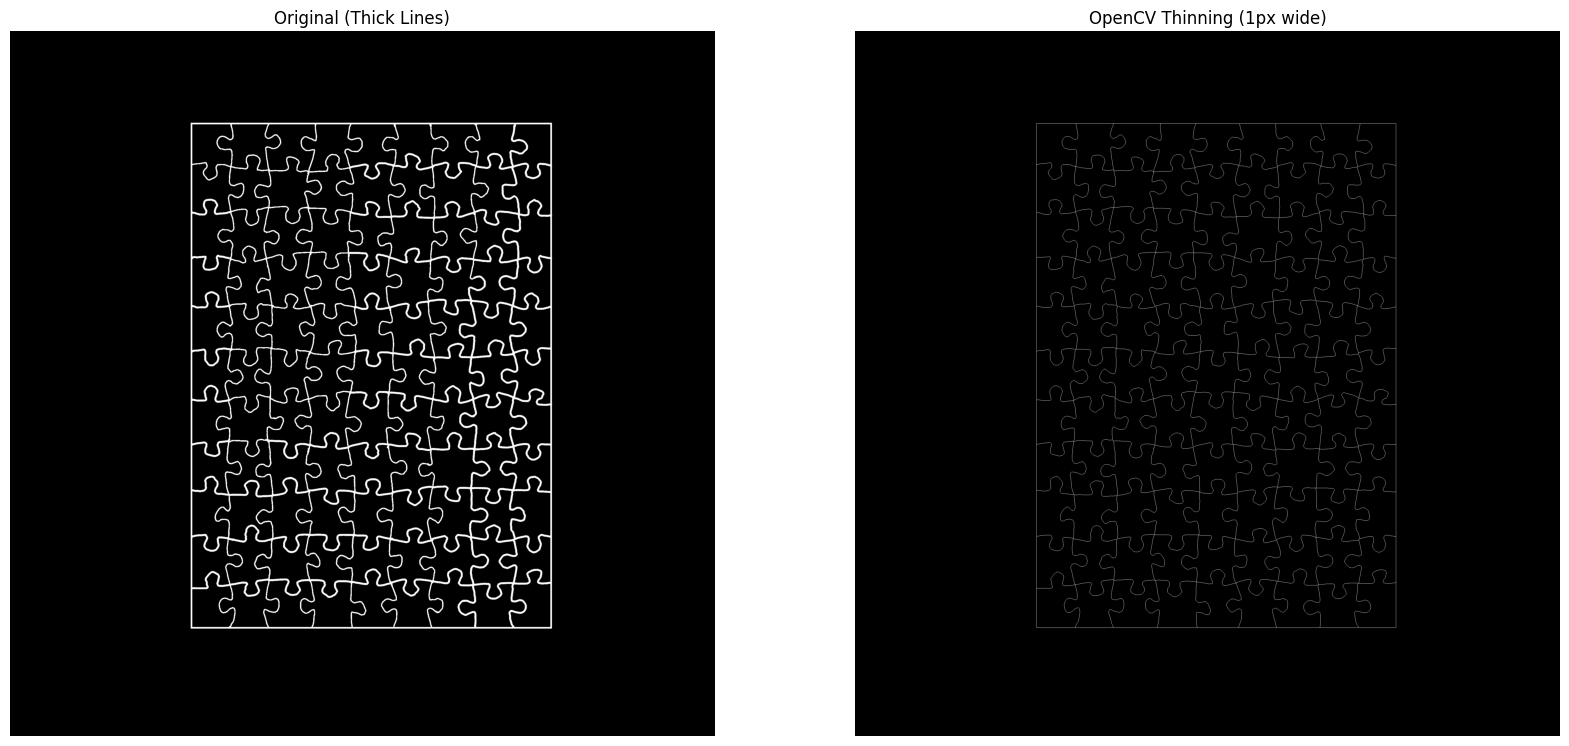

In [11]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.title("Original (Thick Lines)")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("OpenCV Thinning (1px wide)")
plt.imshow(skeleton_visual, cmap='gray')
plt.axis('off')